# **Import libraries**

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# **Load datasets**

In [5]:
employees = pd.read_csv("zenvy_employees_new.csv")
attendance = pd.read_csv("zenvy_attendance_new.csv")
tasks = pd.read_csv("task_assignment_new.csv")

# **View datasets**

In [6]:
print("Employees Data")
display(employees)

Employees Data


,employee_id,name,role
0,101,Rahul,Python Intern
1,102,Priya,Full Stack
2,103,Arjun,Data Science
3,104,Meena,AI/ML
4,105,Kiran,Gen AI


In [7]:
print("Attendance Data")
display(attendance)

Attendance Data


,employee_id,days_present,leaves
0,101,22,2
1,102,20,4
2,103,23,1
3,104,21,3
4,105,24,0


In [8]:
print("Tasks Data")
display(tasks)

Tasks Data


,employee_id,name,task,status
0,101,Rahul,Salary Structure,Pending
1,101,Rahul,Compliance Engine,Pending
2,102,Priya,Approval Workflow,Pending
3,103,Arjun,Dashboard,Pending
4,104,Meena,Risk Model,Pending
5,105,Kiran,Chatbot,Pending


# **Check basic info**

In [10]:
print("Employees shape:", employees.shape)
print("Attendance shape:", attendance.shape)
print("Tasks shape:", tasks.shape)

Employees shape: (5, 3)
Attendance shape: (5, 3)
Tasks shape: (6, 4)


In [11]:
print("\nEmployees columns:", employees.columns.tolist())
print("Attendance columns:", attendance.columns.tolist())
print("Tasks columns:", tasks.columns.tolist())


Employees columns: ['employee_id', 'name', 'role']
Attendance columns: ['employee_id', 'days_present', 'leaves']
Tasks columns: ['employee_id', 'name', 'task', 'status']


# **Check null values**

In [12]:
print("Employees null values")
print(employees.isnull().sum())

print("\nAttendance null values")
print(attendance.isnull().sum())

print("\nTasks null values")
print(tasks.isnull().sum())

Employees null values
employee_id    0
name           0
role           0
dtype: int64

Attendance null values
employee_id     0
days_present    0
leaves          0
dtype: int64

Tasks null values
employee_id    0
name           0
task           0
status         0
dtype: int64


# **Check duplicates**

In [13]:
print("Employees duplicates:", employees.duplicated().sum())
print("Attendance duplicates:", attendance.duplicated().sum())
print("Tasks duplicates:", tasks.duplicated().sum())

Employees duplicates: 0
Attendance duplicates: 0
Tasks duplicates: 0


# **Check Statical Summary**

In [24]:
display("Employees duplicates:", employees.describe())
display("Attendance duplicates:", attendance.describe())
display("Tasks duplicates:", tasks.describe())

'Employees duplicates:'

,employee_id
count,5.000000
mean,103.000000
std,1.581139
min,101.000000
25%,102.000000
50%,103.000000
75%,104.000000
max,105.000000


'Attendance duplicates:'

,employee_id,days_present,leaves
count,5.000000,5.000000,5.000000
mean,103.000000,22.000000,2.000000
std,1.581139,1.581139,1.581139
min,101.000000,20.000000,0.000000
25%,102.000000,21.000000,1.000000
50%,103.000000,22.000000,2.000000
75%,104.000000,23.000000,3.000000
max,105.000000,24.000000,4.000000


'Tasks duplicates:'

,employee_id
count,6.000000
mean,102.666667
std,1.632993
min,101.000000
25%,101.250000
50%,102.500000
75%,103.750000
max,105.000000


# **Clean role column**

In [14]:
employees["role"] = employees["role"].str.strip()
display(employees)

,employee_id,name,role
0,101,Rahul,Python Intern
1,102,Priya,Full Stack
2,103,Arjun,Data Science
3,104,Meena,AI/ML
4,105,Kiran,Gen AI


# **Create task count per employee**

In [15]:
task_count = tasks.groupby("employee_id").size().reset_index(name="task_count")
display(task_count)

,employee_id,task_count
0,101,2
1,102,1
2,103,1
3,104,1
4,105,1


# **Merge employees and attendance**

In [16]:
payroll = employees.merge(attendance, on="employee_id", how="inner")
display(payroll)

,employee_id,name,role,days_present,leaves
0,101,Rahul,Python Intern,22,2
1,102,Priya,Full Stack,20,4
2,103,Arjun,Data Science,23,1
3,104,Meena,AI/ML,21,3
4,105,Kiran,Gen AI,24,0


# **Merge task count**

In [17]:
payroll = employees.merge(attendance, on="employee_id", how="inner")
display(payroll)

,employee_id,name,role,days_present,leaves
0,101,Rahul,Python Intern,22,2
1,102,Priya,Full Stack,20,4
2,103,Arjun,Data Science,23,1
3,104,Meena,AI/ML,21,3
4,105,Kiran,Gen AI,24,0


# **Merge task count**

In [18]:
payroll = payroll.merge(task_count, on="employee_id", how="left")
display(payroll)

,employee_id,name,role,days_present,leaves,task_count
0,101,Rahul,Python Intern,22,2,2
1,102,Priya,Full Stack,20,4,1
2,103,Arjun,Data Science,23,1,1
3,104,Meena,AI/ML,21,3,1
4,105,Kiran,Gen AI,24,0,1


# **Fill missing task count**

In [19]:
payroll["task_count"] = payroll["task_count"].fillna(0).astype(int)
display(payroll)

,employee_id,name,role,days_present,leaves,task_count
0,101,Rahul,Python Intern,22,2,2
1,102,Priya,Full Stack,20,4,1
2,103,Arjun,Data Science,23,1,1
3,104,Meena,AI/ML,21,3,1
4,105,Kiran,Gen AI,24,0,1


# **Create salary map**

In [25]:
salary_map = {
    "Python Intern": 15000,
    "Full Stack": 25000,
    "Data Science": 30000,
    "AI/ML": 32000,
    "Gen AI": 35000
}

# **Calculate salary columns**

In [27]:
payroll["basic_salary"] = payroll["role"].map(salary_map)
payroll["per_day_salary"] = payroll["basic_salary"] / 26
payroll["salary_paid"] = payroll["per_day_salary"] * payroll["days_present"]
payroll["loss_of_pay"] = payroll["per_day_salary"] * payroll["leaves"]

display(payroll[["employee_id", "name", "role", "basic_salary", "salary_paid", "loss_of_pay"]])

,employee_id,name,role,basic_salary,salary_paid,loss_of_pay
0,101,Rahul,Python Intern,15000,12692.307692,1153.846154
1,102,Priya,Full Stack,25000,19230.769231,3846.153846
2,103,Arjun,Data Science,30000,26538.461538,1153.846154
3,104,Meena,AI/ML,32000,25846.153846,3692.307692
4,105,Kiran,Gen AI,35000,32307.692308,0.000000


# **Create ascending date column**

In [29]:
payroll = payroll.sort_values("employee_id").reset_index(drop=True)
payroll["date"] = pd.date_range(start="2025-01-01", periods=len(payroll), freq="MS")
display(payroll[["employee_id", "name", "date"]])

,employee_id,name,date
0,101,Rahul,2025-01-01
1,102,Priya,2025-02-01
2,103,Arjun,2025-03-01
3,104,Meena,2025-04-01
4,105,Kiran,2025-05-01


# **Create month column**

In [31]:
payroll["month"] = payroll["date"].dt.strftime("%b-%Y")
display(payroll[["employee_id", "name", "month"]])

,employee_id,name,month
0,101,Rahul,Jan-2025
1,102,Priya,Feb-2025
2,103,Arjun,Mar-2025
3,104,Meena,Apr-2025
4,105,Kiran,May-2025


# **Monthly payroll trend data**

In [32]:
monthly_payroll = payroll.groupby("month", as_index=False)["salary_paid"].sum()
display(monthly_payroll)

,month,salary_paid
0,Apr-2025,25846.153846
1,Feb-2025,19230.769231
2,Jan-2025,12692.307692
3,Mar-2025,26538.461538
4,May-2025,32307.692308


# **Cost per employee data**

In [34]:
cost_per_employee = payroll[["employee_id", "name", "role", "salary_paid"]]
display(cost_per_employee)

,employee_id,name,role,salary_paid
0,101,Rahul,Python Intern,12692.307692
1,102,Priya,Full Stack,19230.769231
2,103,Arjun,Data Science,26538.461538
3,104,Meena,AI/ML,25846.153846
4,105,Kiran,Gen AI,32307.692308


In [37]:
payroll

,employee_id,name,role,days_present,leaves,task_count,basic_salary,per_day_salary,salary_paid,loss_of_pay,date,month
0,101,Rahul,Python Intern,22,2,2,15000,576.923077,12692.307692,1153.846154,2025-01-01,Jan-2025
1,102,Priya,Full Stack,20,4,1,25000,961.538462,19230.769231,3846.153846,2025-02-01,Feb-2025
2,103,Arjun,Data Science,23,1,1,30000,1153.846154,26538.461538,1153.846154,2025-03-01,Mar-2025
3,104,Meena,AI/ML,21,3,1,32000,1230.769231,25846.153846,3692.307692,2025-04-01,Apr-2025
4,105,Kiran,Gen AI,24,0,1,35000,1346.153846,32307.692308,0.000000,2025-05-01,May-2025


In [36]:
print(payroll.columns)

Index(['employee_id', 'name', 'role', 'days_present', 'leaves', 'task_count',
       'basic_salary', 'per_day_salary', 'salary_paid', 'loss_of_pay', 'date',
       'month'],
      dtype='object')


# **Plot monthly payroll trend**

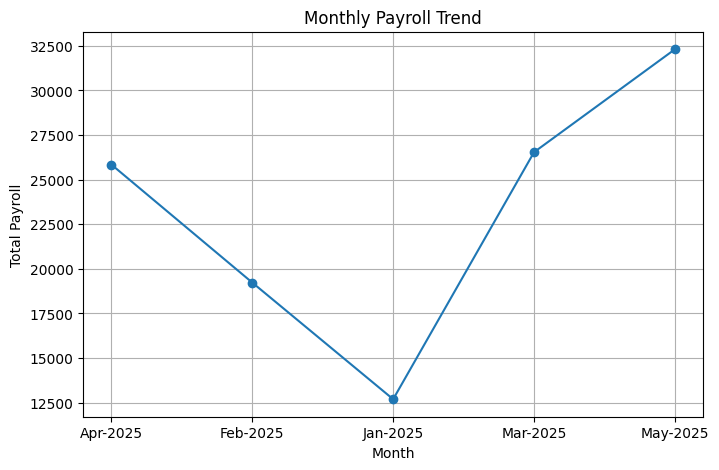

In [38]:
plt.figure(figsize=(8,5))
plt.plot(monthly_payroll["month"], monthly_payroll["salary_paid"], marker="o")
plt.title("Monthly Payroll Trend")
plt.xlabel("Month")
plt.ylabel("Total Payroll")
plt.grid(True)
plt.show()

# **Plot cost per employee**

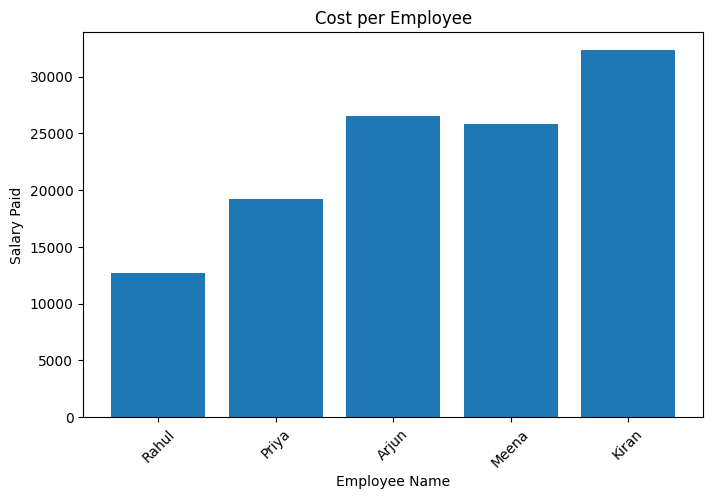

In [39]:
plt.figure(figsize=(8,5))
plt.bar(cost_per_employee["name"], cost_per_employee["salary_paid"])
plt.title("Cost per Employee")
plt.xlabel("Employee Name")
plt.ylabel("Salary Paid")
plt.xticks(rotation=45)
plt.show()

# **Save final file**

In [40]:
payroll.to_csv("final_payroll_with_dates.csv", index=False)
print("File saved successfully")

File saved successfully
